In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

16:59:18 - cmdstanpy - INFO - Chain [1] start processing
16:59:18 - cmdstanpy - INFO - Chain [1] done processing
16:59:19 - cmdstanpy - INFO - Chain [1] start processing
16:59:19 - cmdstanpy - INFO - Chain [1] done processing
16:59:19 - cmdstanpy - INFO - Chain [1] start processing
16:59:19 - cmdstanpy - INFO - Chain [1] done processing


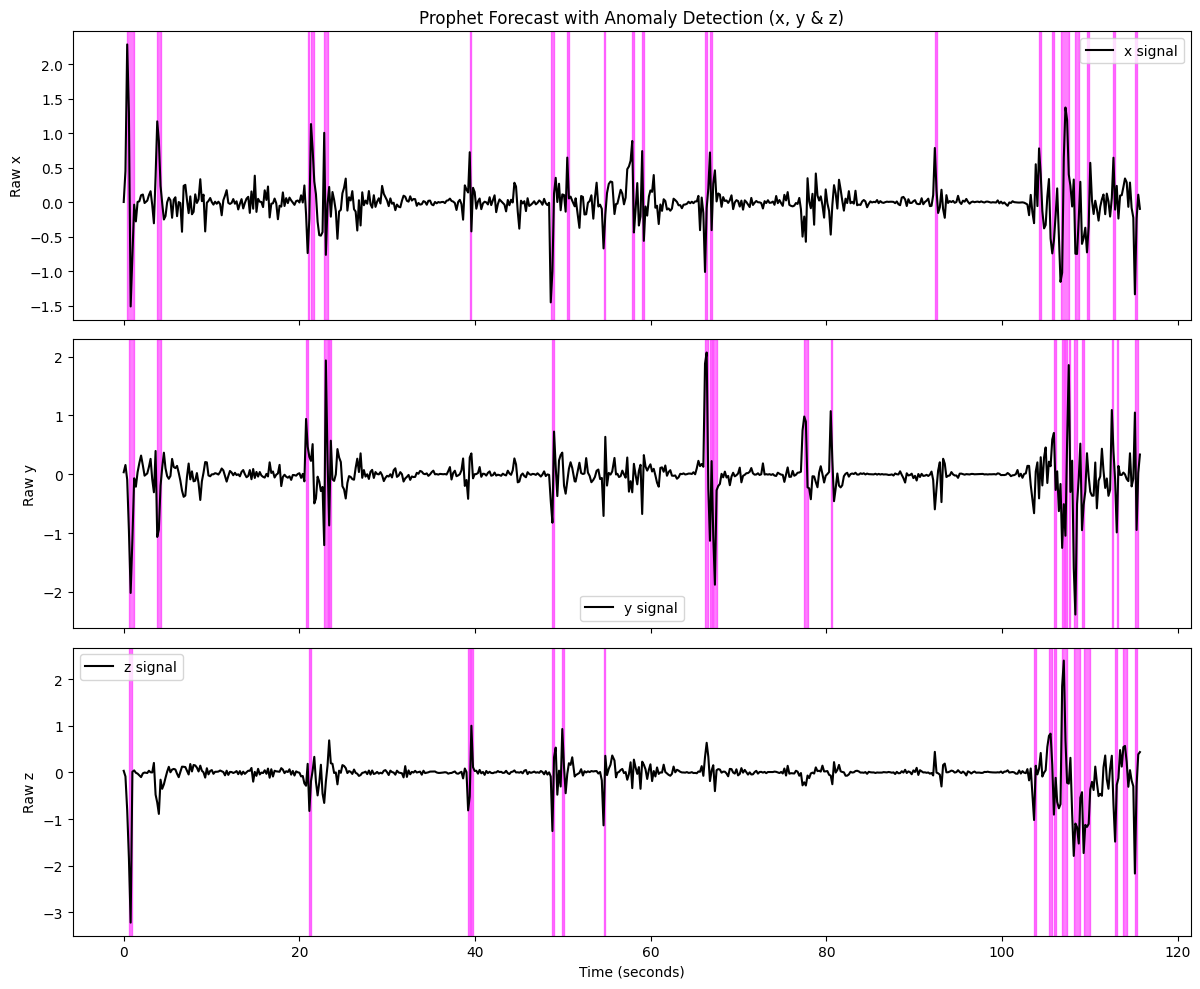

In [ ]:

# Load cleaned gyroscope data
gyro_df = pd.read_csv("gyroscope_cleaned.csv")

# Convert timestamp to seconds elapsed
start_time = pd.to_datetime(gyro_df['Timestamp'].iloc[0])
gyro_df['seconds_elapsed'] = (pd.to_datetime(gyro_df['Timestamp']) - start_time).dt.total_seconds()

# Function to find anomaly segments
def get_anomaly_segments(time, anomalies):
    segments = []
    in_seg = False
    start = None
    for t, a in zip(time, anomalies):
        if a and not in_seg:
            in_seg = True
            start = t
        elif not a and in_seg:
            in_seg = False
            segments.append((start, t))
    if in_seg:
        segments.append((start, time.iloc[-1] if hasattr(time, 'iloc') else time[-1]))
    return segments

time = gyro_df['seconds_elapsed']

### --- X Axis ---
df_prophet_x = pd.DataFrame({
    'ds': pd.to_datetime(time, unit='s'),
    'y': gyro_df['x'].values
})
m_x = Prophet(daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False, changepoint_prior_scale=0.2)
m_x.fit(df_prophet_x)
forecast_x = m_x.predict(df_prophet_x)
error_x = np.abs(df_prophet_x['y'] - forecast_x['yhat'])
thresh_x = error_x.mean() + 2 * error_x.std()
anomalies_x = error_x > thresh_x

### --- Y Axis ---
df_prophet_y = pd.DataFrame({
    'ds': pd.to_datetime(time, unit='s'),
    'y': gyro_df['y'].values
})
m_y = Prophet(daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False, changepoint_prior_scale=0.2)
m_y.fit(df_prophet_y)
forecast_y = m_y.predict(df_prophet_y)
error_y = np.abs(df_prophet_y['y'] - forecast_y['yhat'])
thresh_y = error_y.mean() + 2 * error_y.std()
anomalies_y = error_y > thresh_y

### --- Z Axis ---
df_prophet_z = pd.DataFrame({
    'ds': pd.to_datetime(time, unit='s'),
    'y': gyro_df['z'].values
})
m_z = Prophet(daily_seasonality=False, yearly_seasonality=False, weekly_seasonality=False, changepoint_prior_scale=0.2)
m_z.fit(df_prophet_z)
forecast_z = m_z.predict(df_prophet_z)
error_z = np.abs(df_prophet_z['y'] - forecast_z['yhat'])
thresh_z = error_z.mean() + 2 * error_z.std()
anomalies_z = error_z > thresh_z

# Plotting all three axes
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# X plot
axs[0].plot(time, gyro_df['x'], label="x signal", color="black")
for seg in get_anomaly_segments(time, anomalies_x):
    axs[0].axvspan(seg[0], seg[1], color="magenta", alpha=0.5)
axs[0].set_ylabel("Raw x")
axs[0].set_title("Prophet Forecast with Anomaly Detection (x, y & z)")
axs[0].legend()

# Y plot
axs[1].plot(time, gyro_df['y'], label="y signal", color="black")
for seg in get_anomaly_segments(time, anomalies_y):
    axs[1].axvspan(seg[0], seg[1], color="magenta", alpha=0.5)
axs[1].set_ylabel("Raw y")
axs[1].legend()

# Z plot
axs[2].plot(time, gyro_df['z'], label="z signal", color="black")
for seg in get_anomaly_segments(time, anomalies_z):
    axs[2].axvspan(seg[0], seg[1], color="magenta", alpha=0.5)
axs[2].set_xlabel("Time (seconds)")
axs[2].set_ylabel("Raw z")
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Load Data
df = pd.read_csv('gyroscope_cleaned.csv')

# Convert timestamp to seconds_elapsed
start_time = pd.to_datetime(df['Timestamp'].iloc[0])
df['seconds_elapsed'] = (pd.to_datetime(df['Timestamp']) - start_time).dt.total_seconds()

# Compute RMS of x, y, z
df['rms_xyz'] = np.sqrt((df['x']**2 + df['y']**2 + df['z']**2) / 3)

# NO Standardization anymore
rms_raw = df['rms_xyz'].values

# Convert to supervised format
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X_rms, y_rms = create_sequences(rms_raw, seq_length)

# Reshape for LSTM input
X_rms = X_rms.reshape((X_rms.shape[0], X_rms.shape[1], 1))

# Define LSTM Model
def build_model():
    model = keras.Sequential([
        layers.LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
        layers.LSTM(50),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Build and train
model_rms = build_model()
model_rms.fit(X_rms, y_rms, epochs=20, batch_size=32, validation_split=0.2)

# Save the model
model_rms.save("model_rms_xyz_lstm.h5")
print("LSTM model for RMS(x, y, z) trained and saved as model_rms_xyz_lstm.h5")

Epoch 1/20


C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0380 - val_loss: 0.1049
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0333 - val_loss: 0.0944
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0348 - val_loss: 0.1075
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0338 - val_loss: 0.0968
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0311 - val_loss: 0.0913
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0279 - val_loss: 0.0877
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0384 - val_loss: 0.0939
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0241 - val_loss: 0.0818
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0280 - val_loss: 0.0819
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0248 - val_loss: 0.0830
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0269 - val_loss: 0.0835
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0280 - val_l

LSTM model for RMS(x, y, z) trained and saved as model_rms_xyz_lstm.h5


In [ ]:
# 1) Load your H5 without re‑compiling (so it doesn’t look for "mse")
model = keras.models.load_model("model_rms_xyz_lstm.h5", compile=False)

# 2) Export as a TensorFlow SavedModel directory
#    (no extension on the path, so Keras knows to use SavedModel format)
model.export("saved_model_rms_xyz", include_optimizer=False)

# 3) Create a TFLiteConverter from the SavedModel dir
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_rms_xyz")

# 4) Enable Select TF Ops (to handle the LSTM layers)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# 5) (Optional) Optimize for size/speed
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 6) Perform the conversion
tflite_model = converter.convert()

# 7) Save the .tflite file
with open("model_rms_xyz_lstm.tflite", "wb") as f:
    f.write(tflite_model)

print("model_rms_xyz.tflite has been saved successfully!")

INFO:tensorflow:Assets written to: saved_model_rms_xyz\assets


INFO:tensorflow:Assets written to: saved_model_rms_xyz\assets


Saved artifact at 'saved_model_rms_xyz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2556219010384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219012496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219013072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219011920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219014416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219013264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219013648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219013840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2556219014800: TensorSpec(shape=(), dtype=tf.resource, name=None)
model_rms_xyz.tflite has been saved su

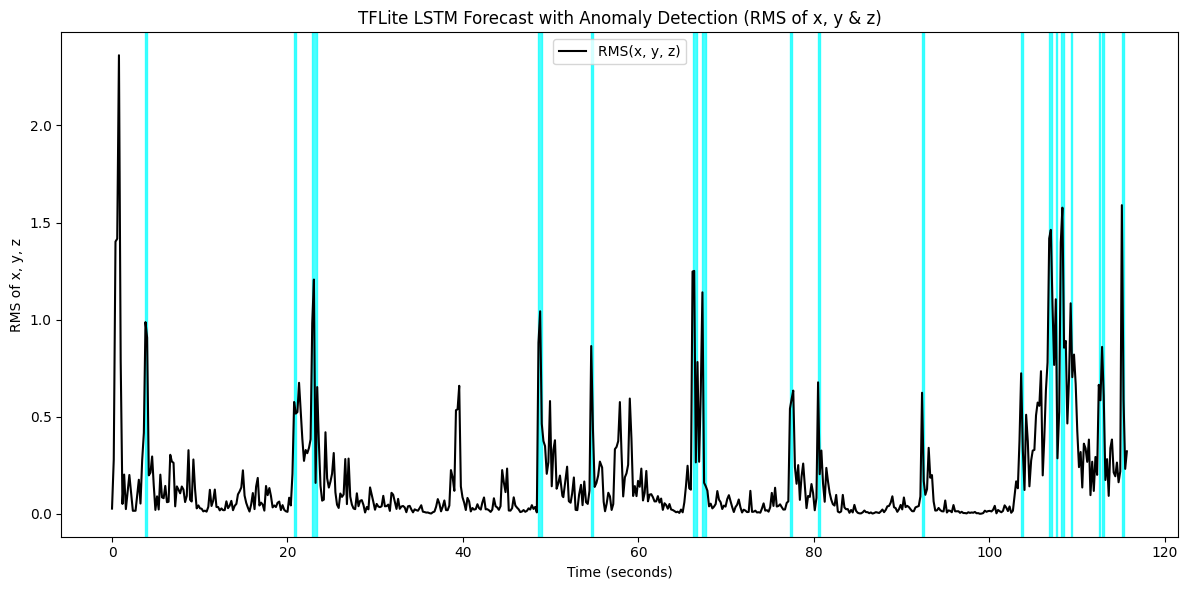

In [ ]:
# Load cleaned gyroscope data
gyro_df = pd.read_csv("gyroscope_cleaned.csv")

# Convert timestamp to seconds elapsed
start_time = pd.to_datetime(gyro_df['Timestamp'].iloc[0])
gyro_df['seconds_elapsed'] = (pd.to_datetime(gyro_df['Timestamp']) - start_time).dt.total_seconds()

# Compute RMS(x, y, z)
gyro_df['rms_xyz'] = np.sqrt((gyro_df['x']**2 + gyro_df['y']**2 + gyro_df['z']**2) / 3)

# Parameters
WINDOW_SIZE = 10
THRESH_MULTIPLIER = 2

# Prepare sliding windows
sequences = []
targets = []
timestamps = []

for i in range(len(gyro_df) - WINDOW_SIZE):
    window = gyro_df['rms_xyz'].iloc[i:i+WINDOW_SIZE].values.reshape(-1, 1).astype(np.float32)
    target = gyro_df['rms_xyz'].iloc[i + WINDOW_SIZE]
    time_point = gyro_df['seconds_elapsed'].iloc[i + WINDOW_SIZE]
    
    sequences.append(window)
    targets.append(target)
    timestamps.append(time_point)

sequences = np.array(sequences)
targets = np.array(targets)
timestamps = np.array(timestamps)

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="model_rms_xyz_lstm.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference
predictions = []

for seq in sequences:
    interpreter.set_tensor(input_details[0]['index'], np.expand_dims(seq, axis=0))
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    predictions.append(output[0][0])

predictions = np.array(predictions)

# Compute absolute error
errors = np.abs(targets - predictions)
threshold = errors.mean() + THRESH_MULTIPLIER * errors.std()
anomalies = errors > threshold

# Define anomaly segments (same logic as in Prophet version)
def get_anomaly_segments(time, anomalies):
    segments = []
    in_seg = False
    start = None
    for t, a in zip(time, anomalies):
        if a and not in_seg:
            in_seg = True
            start = t
        elif not a and in_seg:
            in_seg = False
            segments.append((start, t))
    if in_seg:
        segments.append((start, time[-1]))
    return segments

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(gyro_df['seconds_elapsed'], gyro_df['rms_xyz'], label="RMS(x, y, z)", color="black")

for seg in get_anomaly_segments(timestamps, anomalies):
    plt.axvspan(seg[0], seg[1], color="cyan", alpha=0.7)

plt.xlabel("Time (seconds)")
plt.ylabel("RMS of x, y, z")
plt.title("TFLite LSTM Forecast with Anomaly Detection (RMS of x, y & z)")
plt.legend()
plt.tight_layout()
plt.show()